In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets, Input
import matplotlib.pyplot as plt
import numpy as np
import time

**Загрузка данных и обучение**

---



In [2]:
# Загрузка данных
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# Названия классов в датасете CIFAR-10
class_names = ['самолет', 'авто', 'птица', 'кот', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

In [4]:
# Нормализация (приводим пиксели к диапазону от 0 до 1)
train_images, test_images = train_images / 255.0, test_images / 255.0

In [11]:
# Создание архитектуры CNN (для размера 32x32, как в датасете)
model = models.Sequential([
    # Используем Input слой вместо input_shape в Conv2D
    Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# Обучение
start_time = time.time()

print("Обучение запущено...")
history = model.fit(train_images, train_labels, epochs=7, validation_data=(test_images, test_labels))

total_time = time.time() - start_time

Обучение запущено...
Epoch 1/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.4539 - loss: 1.5124 - val_accuracy: 0.5385 - val_loss: 1.2962
Epoch 2/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 43ms/step - accuracy: 0.5971 - loss: 1.1544 - val_accuracy: 0.6170 - val_loss: 1.0943
Epoch 3/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.6428 - loss: 1.0271 - val_accuracy: 0.6446 - val_loss: 1.0314
Epoch 4/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6720 - loss: 0.9456 - val_accuracy: 0.6599 - val_loss: 0.9896
Epoch 5/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6925 - loss: 0.8829 - val_accuracy: 0.6794 - val_loss: 0.9384
Epoch 6/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7119 - loss: 0.8298 - val_accuracy: 0.6755 - val_loss: 0.9419
Epoch 7/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7285 - loss: 0.7801 - val_accuracy: 0.6720 - val_loss: 0.9736


**Визуализация**

---



In [ ]:
# Функция для вывода результата
def predict_and_show(index):
    img = test_images[index]
    true_label = test_labels[index][0]

    # Модель ожидает массив изображений, поэтому добавляем размерность batch
    img_batch = np.expand_dims(img, axis=0)

    # Получаем предсказание
    prediction = model.predict(img_batch)
    predicted_label = np.argmax(prediction[0])

    # Визуализация
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Реально: {class_names[true_label]}\nНейросеть: {class_names[predicted_label]}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


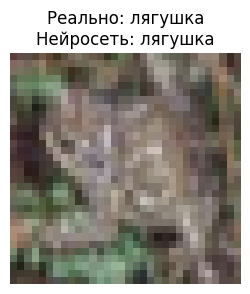

In [ ]:
# Выведем случайное изображение из тестовой выборки
predict_and_show(np.random.randint(0, 1000))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


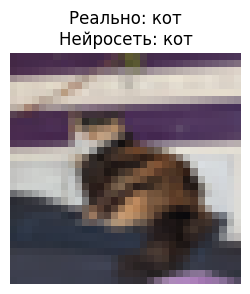

In [ ]:
# Выведем случайное изображение из класса котов
def show_only_cats():
    # Находим индексы всех картинок, где метка (label) равна 3 (это коты)
    cat_indices = np.where(test_labels == 3)[0]

    # Выбираем один случайный индекс из найденных "кошачьих" индексов
    random_cat_idx = np.random.choice(cat_indices)

    # Вызываем функцию предсказания (из предыдущего ответа)
    predict_and_show(random_cat_idx)

show_only_cats()

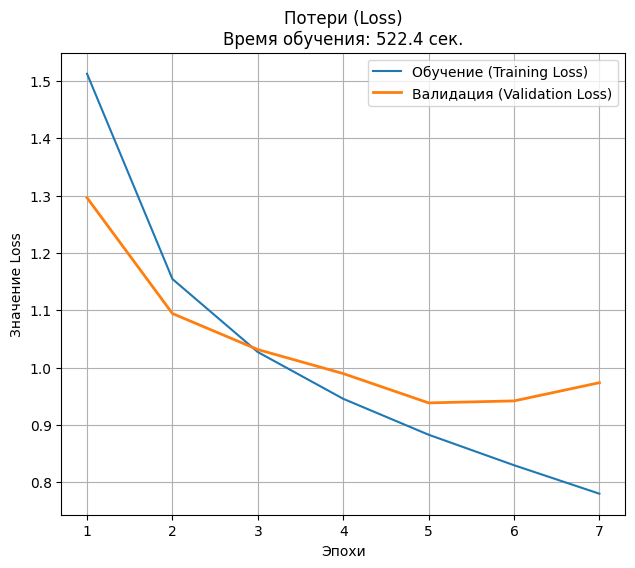

In [ ]:
# Визуализация потерь
def plot_results(history, total_time):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))

    # График: Функция потерь (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Обучение (Training Loss)')
    plt.plot(epochs_range, val_loss, label='Валидация (Validation Loss)', linewidth=2)
    plt.title(f'Потери (Loss)\nВремя обучения: {total_time:.1f} сек.')
    plt.xlabel('Эпохи')
    plt.ylabel('Значение Loss')
    plt.legend(loc='upper right')
    plt.grid(True)



    plt.show()

plot_results(history, total_time)